In [6]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image

In [7]:
def image_tensor(image_path, size=None):
    img = Image.open(image_path)
    
    if size != None:
        img = img.resize(size)

    img = (np.asarray(img)/255.0)
    img = torch.from_numpy(img).float()
    img = img.permute(2,0,1)
    img = img.cuda().unsqueeze(0)
    return img

In [8]:
datasets = {
    'LOL': '/home/soom/data/LOL/eval15',
    'LSRW': '/home/soom/data/LSRW/Eval'
}

def extract_extra_features(img_tensor):
    """
    img_tensor: [1, 3, H, W] - RGB float tensor (0~1 range)
    returns: [5] torch.tensor
    """
    # Convert to grayscale [1, 1, H, W]
    gray = TF.rgb_to_grayscale(img_tensor).squeeze(0)  # [1, H, W]
    gray_flat = gray.flatten()

    # 1. Mean luminance
    mean_luminance = gray_flat.mean().item()

    # 2. Local contrast (std dev of grayscale)
    local_contrast = gray_flat.std().item()

    # 3. Sharpness (Laplacian)
    laplacian_kernel = torch.tensor([[[[-1, -1, -1],
                                       [-1,  8, -1],
                                       [-1, -1, -1]]]], dtype=torch.float32).to(img_tensor.device)
    laplacian = F.conv2d(gray.unsqueeze(0), laplacian_kernel, padding=1)
    sharpness = laplacian.abs().mean().item()

    # 4. Histogram spread (brightness range)
    hist = torch.histc(gray_flat, bins=64, min=0, max=1)
    hist_norm = hist / hist.sum()
    spread = (hist_norm > 0.01).sum().item() / 64.0  # 비율로 정규화

    # 5. Noise estimate (high freq energy)
    sobel_x = torch.tensor([[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]], dtype=torch.float32).to(img_tensor.device)
    edges = F.conv2d(gray.unsqueeze(0), sobel_x, padding=1)
    noise = edges.abs().mean().item()

    return torch.tensor([
        mean_luminance,
        local_contrast,
        sharpness,
        spread,
        noise,
    ], dtype=torch.float32)

In [9]:
# [num_images, 5]

data_path = Path(datasets['LOL'])
image_labels = sorted(os.listdir(data_path / 'low'))
image_features = []
for label in image_labels:            
    lq_224 = image_tensor(data_path / 'low' / label, size=(224, 224))
    extra_feat = extract_extra_features(lq_224)
    image_features.append(extra_feat)    
x_lol = torch.stack(image_features)

In [10]:
data_path = Path(datasets['LSRW'])
image_labels = sorted(os.listdir(data_path / 'low'))
image_features = []
for label in image_labels:            
    lq_224 = image_tensor(data_path / 'low' / label, size=(224, 224))
    extra_feat = extract_extra_features(lq_224)
    image_features.append(extra_feat)    
x_lsrw = torch.stack(image_features)

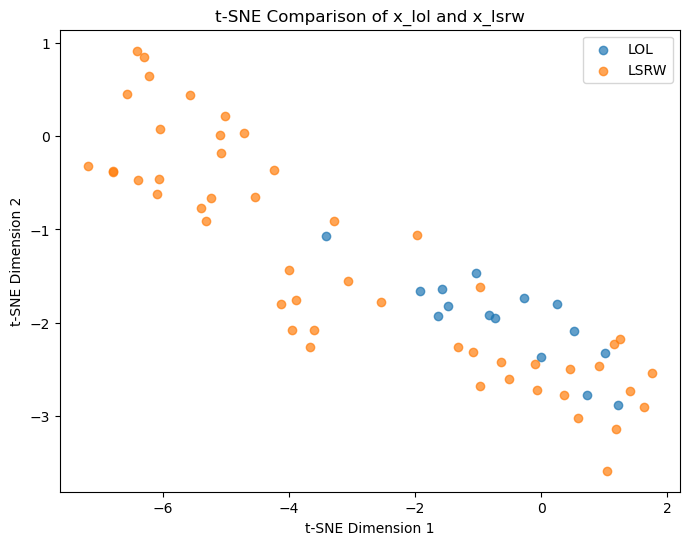

In [11]:
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# Combine the two datasets and create labels
data = torch.cat([x_lol, x_lsrw], dim=0).cpu().numpy()
labels = ['LOL'] * x_lol.size(0) + ['LSRW'] * x_lsrw.size(0)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(data)

# Plot the results
plt.figure(figsize=(8, 6))
for label in set(labels):
    indices = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(data_2d[indices, 0], data_2d[indices, 1], label=label, alpha=0.7)
plt.legend()
plt.title("t-SNE Comparison of x_lol and x_lsrw")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

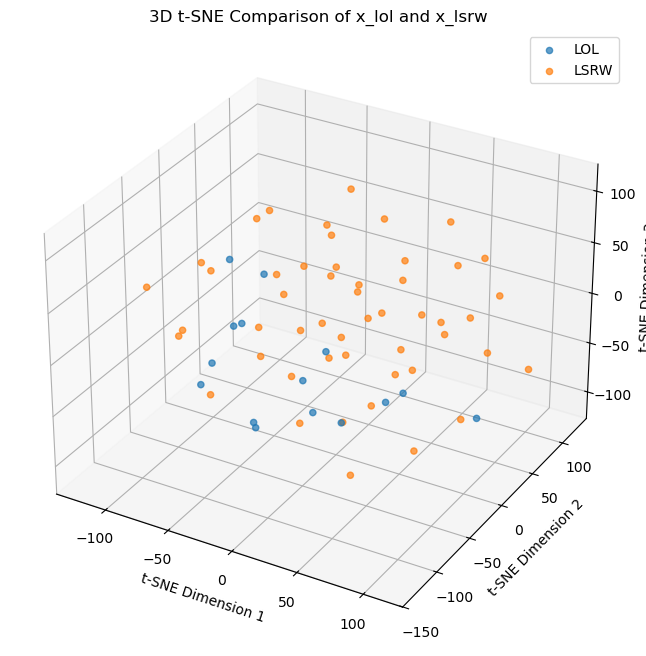

In [12]:
from mpl_toolkits.mplot3d import Axes3D

# Apply t-SNE with 3 components
tsne_3d = TSNE(n_components=3, random_state=42)
data_3d = tsne_3d.fit_transform(data)

# Plot the results in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label in set(labels):
    indices = [i for i, l in enumerate(labels) if l == label]
    ax.scatter(data_3d[indices, 0], data_3d[indices, 1], data_3d[indices, 2], label=label, alpha=0.7)

ax.set_title("3D t-SNE Comparison of x_lol and x_lsrw")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_zlabel("t-SNE Dimension 3")
ax.legend()
plt.show()